Generating the positioning the GNSS
Author: Brandon Engelbrecht

NOTE:
    We make use of the MeerKAT/meerkat_utils package found on GH and owned by Dr. Yi-Chao Li

In [1]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

In [2]:
# Python
import pickle
import sys
import time
from datetime import datetime, timedelta
import pytz
import os
# Python Files
from satellite_RFI.src import check_satellite as cs
from satellite_RFI.src import beam_model as bm
from satellite_RFI.src import rewrite_tle
from satellite_RFI.src import satellite_extract
from satellite_RFI.src import tle_sat_download as tsd
from satellite_RFI.src import tools
# Astropy
from astropy.time import Time
import astropy.units as u
import astropy.constants as cc
# Numpy
import numpy as np
#  Matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as md


### -------------------------------------------- Satellite Position--------------------------------------------

In [3]:
# print """

# obs_time\tUser enters the date and time of observation with respect to UTC time\n\t\tformat: YYYY MM DD hh mm ss

# nd_s\t\tthe scanning timestamps (can leave empty)

# nd_s0\t\ta list of the scan in seconds should be given here,\n\t\tthis is added to the fname/obs_time and can be the\n\t\tscanning zone, in seconds or timestamp seconds

# frequency\ta list of the frequency for the observation\n\t\t(f0, f1, f2....., fn) [Units MHz]

# fs,fe\t\tThe starting and ending point of the frequency [Units MHz]\n
# \t\tIf None, will use the entire frequency band

# timestamps\tcan leave empty

# telescopeLon/Lat The longitude and latitude of the telescope position

# nd_s0_coords\ta tuple of (AZ_list, ALT_list), these should be of\n\t\tequal size and equal to the length of nd_s0
               
# data_save\tlocation to save the data

# tle_location\tlocation of the TLE satellite inforamtion for the observation

# sats_type\tthe different satellite constellations for the satellites:\n\t\tname variable should correspond to the file name xxx.txt

# tle_data_sort\tGiven the format of the TLE from the website, the data needs to be processed first.\n\t\tNone to do nothing
# """

In [274]:
fname_files = [
# '1630519596',
# '1631379874',
# '1631387336',
# '1631659886',
# '1631667564',  
# '1631552188',
# '1631559762', #Issue
# '1631724508',  #Issue could not broadcast input array from shape (2,3,0,4096) into shape (2,3)
# '1631732038',  #Issue
# '1631810671',
# '1631818149',
# '1634835083'
'1631982988'    
    
]

In [275]:
idx = 0

tools.timepoint(fname=float(fname_files[idx]))

datetime.datetime(2021, 9, 18, 18, 36, 28)

In [276]:
for idx in range(len(fname_files)):
    obs_time_input=None
    fname = fname_files[idx]

    tle_location = '../Satellite_position/TLE/2021_09_06_tle/'

    if tle_location==None:
        tle_location=tsd.tle_download(direc_path="TLE/")

    print ("TLE location: "+tle_location) 


    #######################

    """
    Establishing the file name
    """
    if obs_time_input!=None:
        obs_time_in=[int(x) for x in obs_time_input.split()]
        obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
        dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
        fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
        print ("File name to be used is: "+str(fname))

    else:
        print ("File name to be used is: "+str(fname))
        dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
        print ("Date of observation date: "+str(dt))

    ###

    # katdal_info = pickle.load(open('../../../Observation_results/Untangle/'+str(fname)+'/'+str(fname)+'_katdal_info.p', 'rb'))
    katdal_info = pickle.load(open('/users/bengelbrecht/MeerKLASS/katdal_info/'+str(fname_files[idx])+'_katdal_info.p', 'rb'))#,encoding='latin1')
    info = [katdal_info[i] for i in katdal_info.keys()]

    katdal_idx = pickle.load(open('/users/bengelbrecht/MeerKLASS/katdal_info/'+str(fname_files[idx])+'_katdal_idx.p', 'rb'))#,encoding='latin1')
    k_idx = [katdal_idx[i] for i in katdal_idx.keys()]

    katdal_survey = pickle.load(open('/users/bengelbrecht/MeerKLASS/katdal_info/'+str(fname_files[idx])+'_katdal_survey.p', 'rb'))#,encoding='latin1')
    survey = [katdal_survey[i] for i in katdal_survey.keys()]

    ##################################

    nd_s0=katdal_info['nd_s0']
    nd_s0_coords=katdal_info['nd_s0_coords']

    nd_t0=katdal_info['nd_t0']
    nd_t0_coords=katdal_info['nd_t0_coords']

    survey_time = survey[2] - survey[2][0]
    survey_el, survey_az = katdal_survey['el'], katdal_survey['az']

    nd_t0a_idx = katdal_idx['nd_t0_idx'][katdal_idx['nd_t0_idx'] < 1000]
    nd_t0b_idx = katdal_idx['nd_t0_idx'][katdal_idx['nd_t0_idx'] > 1000]
    nd_s0_idx = katdal_idx['nd_s0_idx']

    ###############################

    frequency=katdal_info['frequency']
    fs=1000
    fe=1500
    telescope_Lon =  (21. + 26./60. + 38.00/3600.) * u.deg #
    telescope_Lat = -(30. + 42./60. + 47.41/3600.) * u.deg #
    # data_save='../../../Observation_results/Untangle/'+str(fname)+'/'


    sats_type =['gps-ops', 'glo-ops', 'galileo', 'beidou', 'irnss', 'qzs', 'sbas']   
    tle_data_sort=None

    """
    Rewriting the TLE data
    """
    if tle_data_sort is not None: 
        print ('Extracting IRNSS and QZs')
        satellite_extract.sat_extract(folder=tle_location)
        print ('Extract complete ')
        print ('Re-writing data')
        rewrite_tle.rewrite_sat_cat(file_path=tle_location)
        print ('Re-write completed')



    ###############################


    """
    Python CLASS to initialize the data
    """
    tsc = cs.Telescopesite_Satellite_Catalogue(source_url=tle_location, 
                                             sats_type=sats_type, 
                                             reload=False)

    tsc.obs_time= datetime.utcfromtimestamp(int(fname)+survey_time[0]).strftime('%Y-%m-%d %H:%M:%S')
    tsc.obs_time_list = (survey_time) * u.second

    tsc.obs_location = [telescope_Lat, telescope_Lon]

    tsc.get_sate_coords()

    #################################

    """
    Satellite Pointing coordinates
    """
    telescope_pointing =  np.array([[survey_az[:,0][i], survey_el[:,0][i]] for i 
                          in range(len(survey_az[:,0]))])

    ##############

    """
    Satellite position on the sky with respect to the telescope
    """

    satellite_angle = tsc.check_angular_separation(
        pointings=telescope_pointing, max_angle=100, beam_func=None, 
        ymin=1e-10, ymax=1, axes=None)


    for i in range(len(tsc.sats_type_remain)):
    #     print "Satellite angles for: ", tsc.sats_type_remain[i]
        satellite_angle[i] = satellite_angle[i].T

    ############

    for i in range(len(tsc.sats_type_remain)):
        fig = plt.figure(figsize=(12,6))

        ax1 = plt.subplot(212)
        ax2 = plt.subplot(221)
        ax3 = plt.subplot(222)

        for sats in satellite_angle[i]:
            ax1.plot(survey_time[nd_s0_idx], sats[nd_s0_idx])

            ax2.plot(survey_time[nd_t0a_idx], sats[nd_t0a_idx])

            ax3.plot(survey_time[nd_t0b_idx], sats[nd_t0b_idx])


        ax1.set_title('Scan')
        ax1.axhline(0, color='red', linestyle='--', label= '0 degree')
        ax1.axhline(5, color='black', linestyle='--', label= '5 degree')
        ax1.set_ylim(-2, 110)    

        ax2.set_title('Track (I)')
        ax2.axhline(0, color='red', linestyle='--', label= '0 degree')
        ax2.axhline(5, color='black', linestyle='--', label= '5 degree')
        ax2.set_ylim(-2,110)    

        ax3.set_title('Track (II)')
        ax3.axhline(0, color='red', linestyle='--', label= '0 degree')
        ax3.axhline(5, color='black', linestyle='--', label= '5 degree')
        ax3.set_ylim(-2, 110)


        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

        fig.suptitle(dt+'-[GMT] '+tsc.sats_type_remain[i]+' constellation with respect to MKAT pointing', y=1.03)    
        fig.text(0.5, 0.001, 'Time [sec]', ha='center', va='center')
        fig.text(0.001, 0.5, 'Angular distance [deg]', ha='center', va='center', rotation='vertical')


        plt.tight_layout()
        plt.savefig('/users/bengelbrecht/MeerKLASS/Busy_week/Satellite_movement/'+str(fname_files[idx])+'_'+tsc.sats_type_remain[i]+'_satellite_distance_ALL.png', bbox_inches = "tight")

        plt.close()


TLE location: ../Satellite_position/TLE/2021_09_06_tle/
File name to be used is: 1631982988
Date of observation date: 2021-09-18 16:36:28
load sat catalogue from ../Satellite_position/TLE/2021_09_06_tle/ gps-ops.txt
load sat catalogue from ../Satellite_position/TLE/2021_09_06_tle/ glo-ops.txt
load sat catalogue from ../Satellite_position/TLE/2021_09_06_tle/ galileo.txt
load sat catalogue from ../Satellite_position/TLE/2021_09_06_tle/ beidou.txt
load sat catalogue from ../Satellite_position/TLE/2021_09_06_tle/ irnss.txt
load sat catalogue from ../Satellite_position/TLE/2021_09_06_tle/ qzs.txt
load sat catalogue from ../Satellite_position/TLE/2021_09_06_tle/ sbas.txt
Time range 2021-09-18 16:36:28.000 - 2021-09-18 18:38:44.896
Satellite      gps-ops has   16 satellites  [use   7.56 s]
Satellite      glo-ops has   14 satellites  [use   6.33 s]
Satellite      galileo has   13 satellites  [use   5.93 s]
Satellite       beidou has   25 satellites  [use  10.61 s]
Satellite        irnss has   

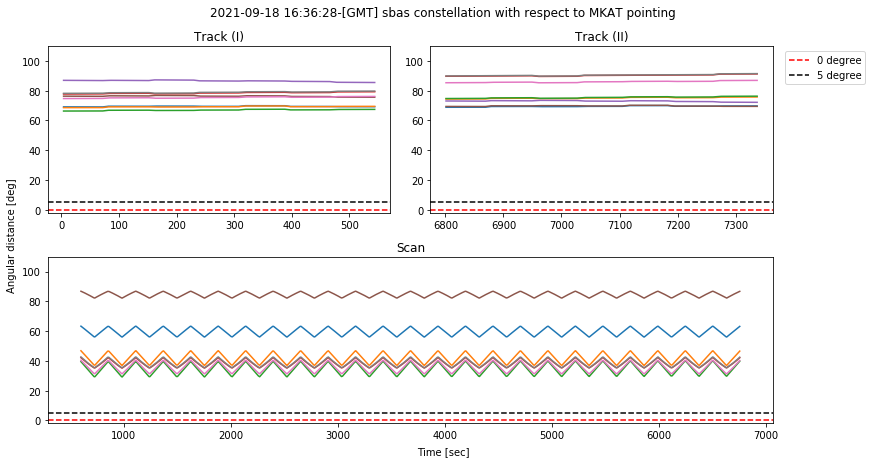

In [277]:
fig = plt.figure(figsize=(12,6))

ax1 = plt.subplot(212)
ax2 = plt.subplot(221)
ax3 = plt.subplot(222)

for sats in satellite_angle[i]:
    ax1.plot(survey_time[nd_s0_idx], sats[nd_s0_idx])

    ax2.plot(survey_time[nd_t0a_idx], sats[nd_t0a_idx])

    ax3.plot(survey_time[nd_t0b_idx], sats[nd_t0b_idx])


ax1.set_title('Scan')
ax1.axhline(0, color='red', linestyle='--', label= '0 degree')
ax1.axhline(5, color='black', linestyle='--', label= '5 degree')
ax1.set_ylim(-2, 110)    

ax2.set_title('Track (I)')
ax2.axhline(0, color='red', linestyle='--', label= '0 degree')
ax2.axhline(5, color='black', linestyle='--', label= '5 degree')
ax2.set_ylim(-2,110)    

ax3.set_title('Track (II)')
ax3.axhline(0, color='red', linestyle='--', label= '0 degree')
ax3.axhline(5, color='black', linestyle='--', label= '5 degree')
ax3.set_ylim(-2, 110)


plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle(dt+'-[GMT] '+tsc.sats_type_remain[i]+' constellation with respect to MKAT pointing', y=1.03)    
fig.text(0.5, 0.001, 'Time [sec]', ha='center', va='center')
fig.text(0.001, 0.5, 'Angular distance [deg]', ha='center', va='center', rotation='vertical')


plt.tight_layout()

Extracting IRNSS and QZs
Extract complete 
Re-writing data
Re-write completed


### --------------------------------------------------------------------------
Setting up pointing paramters and satellite angular values

### ----------------------------------------------------------------------------------------
Plotting angualr seperation of satellites

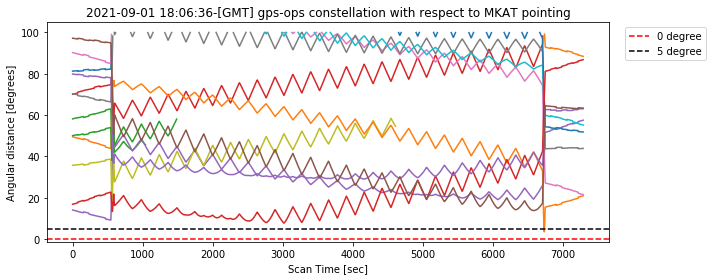

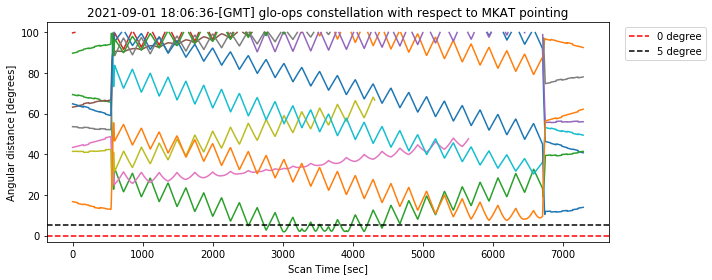

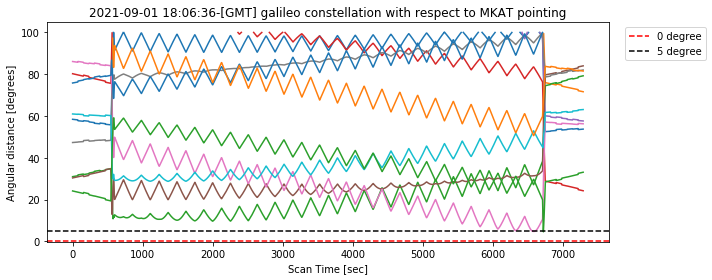

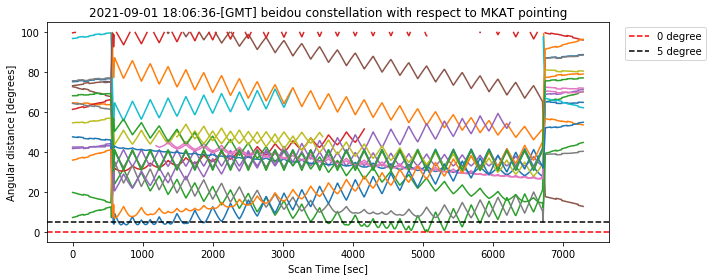

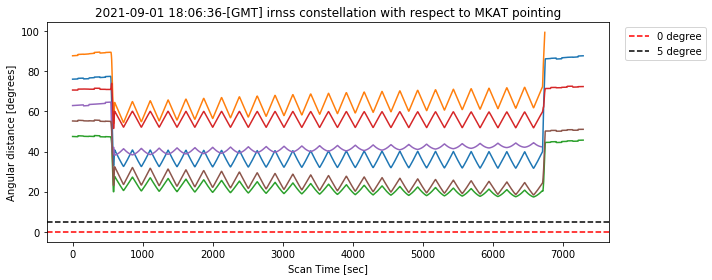

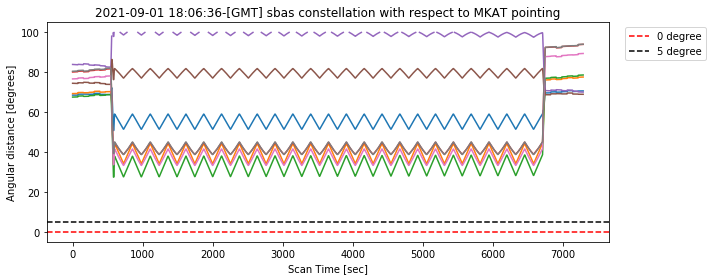

In [180]:
# for i in range(len(tsc.sats_type_remain)):
#     plt.figure(figsize=(10, 4))
    
#     for j in satellite_angle[i]:
#         plt.plot(survey_time, j)
#     plt.axhline(0, color='red', linestyle='--', label= '0 degree')
#     plt.axhline(5, color='black', linestyle='--', label= '5 degree')


#     plt.title(dt+'-[GMT] '+tsc.sats_type_remain[i]+' constellation with respect to MKAT pointing')
#     plt.xlabel('Scan Time [sec]')
#     plt.ylabel('Angular distance [degrees]')  # Make a some symbol name
#     plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
#     plt.tight_layout()
# #     plt.savefig('/users/bengelbrecht/MeerKLASS/Busy_week/Satellite_movement/'+str(fname_files[idx])+'_'+tsc.sats_type_remain[i]+'_satellite_distance_track.png')
#     plt.show()



### ----------------------------------------------------------------------------------------

In [80]:
stop

NameError: name 'stop' is not defined

Function that build multiple observations

In [ ]:
dates=[datetime.fromtimestamp(ts) for ts in int(fname)+nd_s0]
datenums=md.date2num(dates)

In [ ]:
def date_time(day):
    '''
    Enter the day in str format (YYYY-MM-DD)
    '''
    return datetime.strptime(day, "%Y-%m-%d")

def observation_window(first_date, last_date, start_time):
    '''
    Returns the different start times for an observation, given the initial date, the final date and the time it should run for all those dates
    date format: YYYY-MM-DD
    time_format: hh:mm:ss
    '''
    
    sdate = date_time(first_date)
    edate = date_time(last_date)

    delta = edate - sdate       # as timedelta
    stime = datetime.strptime(start_time, '%H:%M:%S')
    stime_delta =timedelta(hours=stime.hour, minutes=stime.minute, seconds=stime.second)

    windows = []
    for i in range(delta.days + 1):
        observation_start = sdate + timedelta(days=i) + stime_delta
        windows.append(observation_start.strftime("%Y-%m-%d %H:%M:%S"))

    return np.array(windows)



# User input the start day length of the observation
start_date = '2021-09-20'
end_date = '2021-09-22'

sdate = date_time(start_date)
edate = date_time(end_date)

# time of the observation
start_time = '20:00:00'

# Observartion time window
obs_time_window = observation_window(first_date=start_date, last_date=end_date, start_time=start_time)

In [ ]:
def daily_time_observation():
    '''
    Function that should provide daily checks of the satellites for a given time range
    Work in progress.....
    '''

    # Initalizing the time
    tsc = cs.Telescopesite_Satellite_Catalogue(source_url=tle_location, 
                                             sats_type=sats_type, 
                                             reload=False)

    tsc.obs_location = [telescope_Lat, telescope_Lon]

    telescope_pointing =  np.array([[nd_s0_coords[0][i], nd_s0_coords[1][i]] for i 
                          in range(len(nd_s0_coords[0]))])


    obs_time_window_sats = []
    obs_time_window_cons = []

    # Running for each observation window
    for i in obs_time_window:
        tsc.obs_time=i
        tsc.obs_time_list = nd_s0 * u.second

        tsc.get_sate_coords()

        # Calculationg the satellite angle
        satellite_angle = tsc.check_angular_separation(
            pointings=telescope_pointing, max_angle=100, beam_func=None, 
            ymin=1e-10, ymax=1, axes=None)

        # Tranposing each constellation 
        for i in range(len(tsc.sats_type_remain)):
            satellite_angle[i] = satellite_angle[i].T

        obs_time_window_cons.append(tsc.sats_type_remain)
        obs_time_window_sats.append(satellite_angle)

    print ('Done')
    obs_time_window_sats = np.array(obs_time_window_sats)
    
    # Plotting

    fig, axs = plt.subplots(obs_time_window_sats.shape[0], obs_time_window_sats.shape[1], 
                            sharex=True, sharey=True, figsize=(10*obs_time_window_sats.shape[0], 5*obs_time_window_sats.shape[0]))
    fig.suptitle(str(obs_time_window_sats.shape[0])+'-Day Observation @ '+start_time, y=1.01, fontsize=28)

    for const in range(obs_time_window_sats.shape[1]): # looping through constellation

        for timeline in range(obs_time_window_sats[:, const].shape[0]):
            if len(np.ma.where(obs_time_window_sats[timeline,const] < 5)[0]) !=0:
                axs[timeline, const].set_facecolor('xkcd:yellow orange')
                axs[timeline, const].patch.set_alpha(0.2)

            else:
                axs[timeline, const].set_facecolor('xkcd:pale green')
                axs[timeline, const].patch.set_alpha(0.2)

            if len(np.ma.where(obs_time_window_sats[timeline,const] < 1)[0]) !=0:
                axs[timeline, const].set_facecolor('xkcd:pale red')
                axs[timeline, const].patch.set_alpha(0.2)

            for sat in range(obs_time_window_sats[timeline, const].shape[0]):
                axs[timeline, const].plot(nd_s0, obs_time_window_sats[timeline, const][sat])          

                axs[timeline, const].axhline(0, color='red', linestyle='--', label= '0 degree')
                axs[timeline, const].axhline(5, color='black', linestyle='--', label= '5 degree')

                axs[0, const].set_title(tsc.sats_type_remain[const], rotation=0, fontsize=20, weight="bold")
                axs[timeline, 0].set_ylabel(obs_time_window[timeline]+'\nAngular Seperation [Deg]', rotation=90,fontsize=15)
                axs[-1, const].set_xlabel('Time [sec]', rotation=0, fontsize=15)

    plt.tight_layout()
#     plt.savefig('../../Outputs/Jy_test/'+str(obs_time_window_sats.shape[0])+'_day_observation: '+start_time+'_.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
# daily_time_observation()

### -------------------------------------------------------------

Calculating the constellation seperation angles

In [ ]:
def satellite_timestream(frequency, pointing_position):
    '''
    Produces the angular seperation plots for the freqeuncy given and pointing
    Uses some global variabes like 
    Frequency - ini, end, channel'''
    
    ## Code from satellite_timestream
    freq = frequency  
    # beam_func = bm.Khans_beam_model(freq=freq)
    # beam_func = bm.Cosine_beam_model(freq=freq)       # using cosine beam model
    # beam_func = bm.emss_beam_model(f=freq)              # using meerkat model beam
    beam_func = bm.khan_emss_beam_model(f=freq)         # using symmetric Khan beam and EMSS beam


    stype, sname, stemperature = [], [], []

    for _sat_info in tsc.itersats_temperature(pointings=pointing_position, beam_func=beam_func, close_angle=None):
        _sat_type, _sat_names, _temperature = _sat_info
        print 'Sat. Name includes %s ...'%_sat_names[0] # includes the name of each sat
        print 'N_freq x N_time x N_sats = %d x %d x %d '%_temperature.shape
        print
        np.array(stype.append(_sat_type)), sname.append(_sat_names), stemperature.append(np.sum(_temperature[:,:,:], axis=2))

        del _temperature 
    return stype, sname, np.array(stemperature)


In [ ]:
"""
Frequency and frequency channels
"""
if fs and fe is not None: 
    channel_start_idx = (np.where(frequency > fs)[0][0])
    channel_end_idx = (np.where(frequency > fe)[0][0]) 

elif fs is None and fe is not None:
    channel_start_idx = frequency[0]
    channel_end_idx = (np.where(frequency > fe)[0][0]) 

elif fs is not None and fe is None:
    channel_start_idx = (np.where(frequency > fs)[0][0])
    channel_end_idx = frequency[-1]

frequency_band = frequency[channel_start_idx-1:channel_end_idx+1]

print 'Frequency band:', frequency_band

In [ ]:
sat_type, sat_names, stemperature = satellite_timestream(
    frequency=frequency_band, pointing_position=telescope_pointing)

In [ ]:
# w = 10
# h = 10
# fig = plt.figure(figsize=(22, 16))
# columns = 7
# rows = 7
# for i in range(1, columns*rows +1):
#     try:
#         img = stemperature[:,:,i-1]
#     except IndexError:
#         continue
#     fig.add_subplot(rows, columns, i)
#     plt.title('Satellite: '+str(i-1))
#     a_img = plt.imshow(img, aspect='auto', extent=[nd_s0[0], nd_s0[-1], frequency_band[-1], frequency_band[0]])
#     plt.ylabel('Frequency [MHz]')
#     plt.xlabel('Time [sec]')
#     plt.colorbar(a_img)

# plt.tight_layout()
# # plt.savefig('../../../Plots/'+fname+'_emss_beam_gps_all2.png')
# plt.show()

In [ ]:
# Created a dictionary and pickled values for the GPS, Galileo, GLO and Bei

sat_pos = {
    'sat_name': sat_type,
    'angular': stemperature 
}

pickle.dump(sat_pos, open(data_save+str(fname)+"_satellite_angular_position_beam_KE.p", "wb"))

In [ ]:
print 'end @ ' + time.asctime(time.localtime(time.time())) +'#'

### -----------------------------------------------------END-------------------------------------------------------

In [ ]:
path1 = '../../../Observation_results/Untangle/1551055211/1551055211_satellite_angular_position_beam_E.p'
path2 = '../../../Observation_results/Untangle/1551055211/1551055211_satellite_angular_position_emss_beam_r.p'
path3 = '../../../Observation_results/Untangle/1551055211/1551055211_satellite_angular_position_beam_KE.p'

In [ ]:
t1 = pickle.load(open(path1))
# t2 = pickle.load(open(path2))
# t3 = pickle.load(open(path3))

In [ ]:
for i, name in enumerate(t2['sat_name']):
    dic = {
        'sat_name' : t2['sat_name'][i],
        'angular' : [t2['angular'][i]]
    }
    pickle.dump(dic, open('../../../Observation_results/Untangle/1551055211/1551055211_satellite_angular_position_emss_beam_r_'+name+'.p', "wb"))
    

In [ ]:
dic